In [2]:
import pandas as pd
df = pd.read_parquet(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.parquet")

In [3]:
df.head()

,minute,day,cluster,arrivals_ps,servers,svc_p50_ms,svc_p99_ms,cold_n,cold_ms,req_bytes,split
0,0,0,1,474.400000,166.053711,48.573833,519.628320,46,1399.541522,3806.992650,train
1,0,0,2,930.947388,113.453660,48.573833,519.628320,59,1387.795814,3806.992650,train
2,0,0,3,824.012308,118.497500,48.573833,519.628320,37,1143.041000,3806.992650,train
3,0,0,4,593.173638,112.995129,48.573833,519.628320,37,1428.555351,3806.992650,train
4,1,0,1,430.739468,134.532752,50.293662,437.373139,17,999.169765,3557.576564,train


In [5]:
daily = (
    df.groupby(["day", "cluster"])["arrivals_ps"].mean().reset_index()
)

In [7]:
print(daily.head(20))

    day  cluster  arrivals_ps
0     0        1   362.013611
1     0        2   710.403932
2     0        3   628.802004
3     0        4   452.649516
4     1        1   368.704421
5     1        2   723.533764
6     1        3   640.423653
7     1        4   461.015478
8     2        1   342.607805
9     2        2   672.322600
10    2        3   595.094959
11    2        4   428.385157
12    3        1   345.155755
13    3        2   677.322615
14    3        3   599.520638
15    3        4   431.571026
16    4        1   348.320462
17    4        2   683.532935
18    4        3   605.017597
19    4        4   435.528068


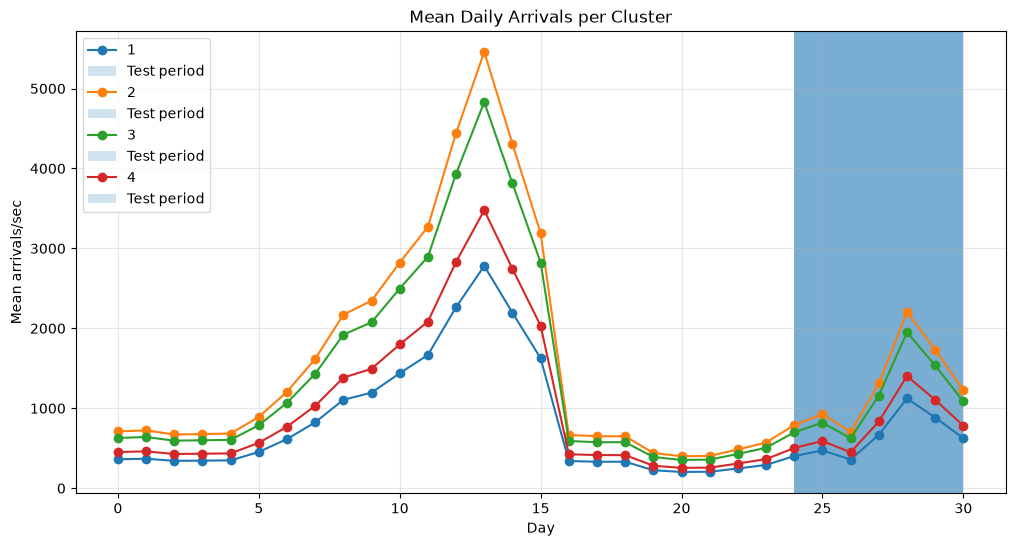

In [13]:
import matplotlib.pyplot as plt

fig , ax  = plt.subplots(figsize=(12, 6))

# Loops 4 times for 4 clusters that are present 

for cluster, group in daily.groupby("cluster"):
    ax.plot(
        group["day"],
        group["arrivals_ps"],
        marker="o",
        label=cluster
    )

    ax.axvspan(
        24,
        30,
        alpha = 0.2,
        label = "Test period"
    )
ax.set_xlabel("Day")
ax.set_ylabel("Mean arrivals/sec")
ax.set_title("Mean Daily Arrivals per Cluster")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


In [15]:
import json 
with open(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.json","r") as f:
    data = json.load(f)

In [17]:
low_days = data["candiate_detector"]["days"]
print(low_days)

[9, 15]


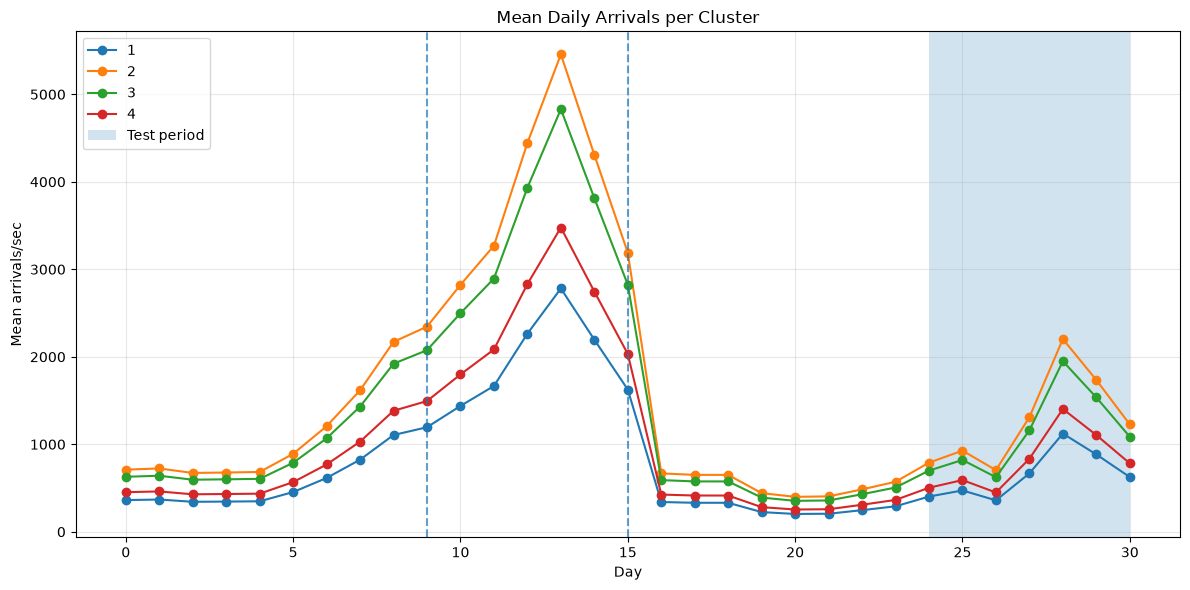

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot one line per cluster
for cluster, group in daily.groupby("cluster"):
    ax.plot(
        group["day"],
        group["arrivals_ps"],
        marker="o",
        label=cluster
    )

# Test period: days 24–30
ax.axvspan(
    24,
    30,
    alpha=0.2,
    label="Test period"
)

# Holidays from JSON
for day in low_days:
    ax.axvline(
        day,
        linestyle="--",
        alpha=0.7
    )

ax.set_xlabel("Day")
ax.set_ylabel("Mean arrivals/sec")
ax.set_title("Mean Daily Arrivals per Cluster")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
df.head()

,minute,day,cluster,arrivals_ps,servers,svc_p50_ms,svc_p99_ms,cold_n,cold_ms,req_bytes,split
0,0,0,1,474.400000,166.053711,48.573833,519.628320,46,1399.541522,3806.992650,train
1,0,0,2,930.947388,113.453660,48.573833,519.628320,59,1387.795814,3806.992650,train
2,0,0,3,824.012308,118.497500,48.573833,519.628320,37,1143.041000,3806.992650,train
3,0,0,4,593.173638,112.995129,48.573833,519.628320,37,1428.555351,3806.992650,train
4,1,0,1,430.739468,134.532752,50.293662,437.373139,17,999.169765,3557.576564,train


the busy hours each day, weekday vs. weekend differences

In [21]:
df["hour"] = (df["minute"] // 60 ) % 24

print(df["hour"])

0          0
1          0
2          0
3          0
4          0
          ..
178555    23
178556    23
178557    23
178558    23
178559    23
Name: hour, Length: 178560, dtype: int64


In [24]:
per_cluster = (
    df.groupby(["cluster","day","hour"])["arrivals_ps"].mean().reset_index()
)

In [25]:
print(per_cluster)

      cluster  day  hour  arrivals_ps
0           1    0     0   386.908012
1           1    0     1   313.773867
2           1    0     2   395.974123
3           1    0     3   438.203721
4           1    0     4   436.923263
...       ...  ...   ...          ...
2971        4   30    19   119.322173
2972        4   30    20   102.113569
2973        4   30    21   383.537015
2974        4   30    22   162.205534
2975        4   30    23   390.522849

[2976 rows x 4 columns]


C:\Users\Aarya-2\AppData\Local\Temp\ipykernel_28320\1292051390.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


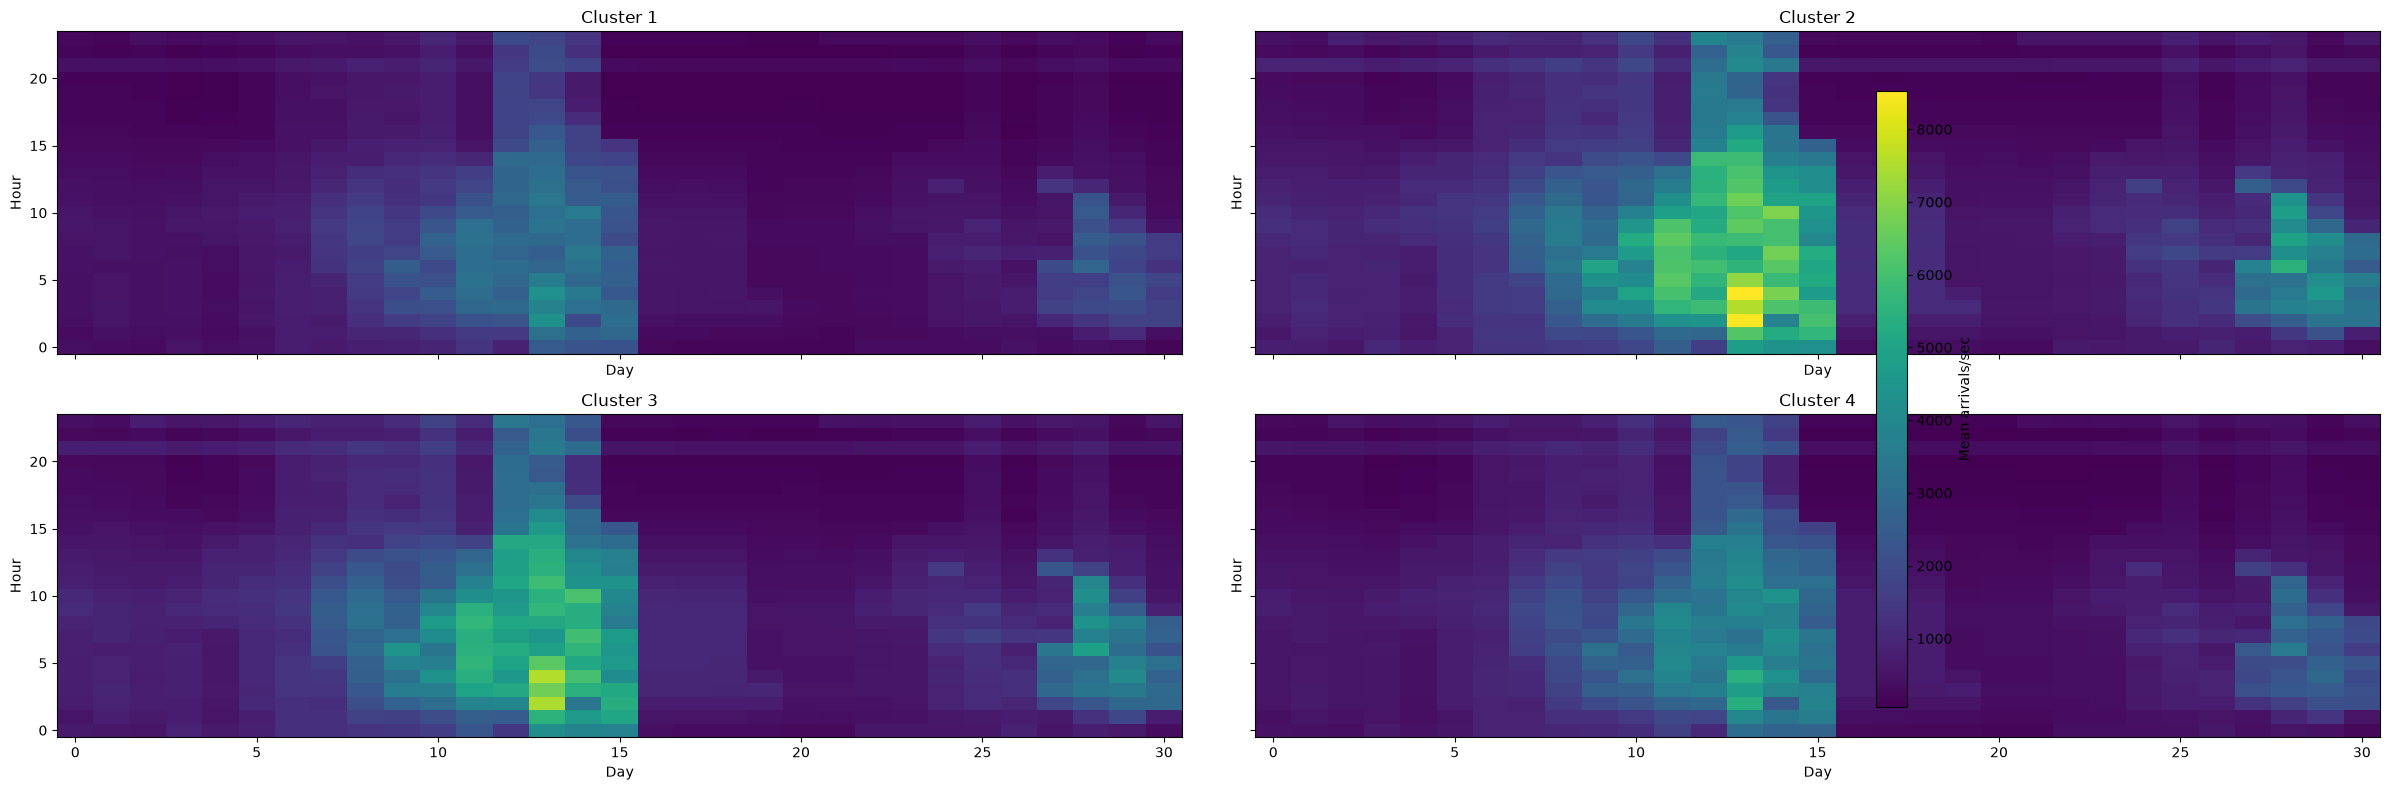

In [28]:
import matplotlib.pyplot as plt

clusters = per_cluster["cluster"].unique()

fig, axes = plt.subplots(
    2, 2,
    figsize=(24, 8),
    sharex=True,
    sharey=True
)

# Find one common colour scale for ALL clusters
vmin = per_cluster["arrivals_ps"].min()
vmax = per_cluster["arrivals_ps"].max()

for ax, cluster in zip(axes.flat, clusters):

    cluster_data = per_cluster[
        per_cluster["cluster"] == cluster
    ]

    # rows = hours, columns = days
    grid = cluster_data.pivot(
        index="hour",
        columns="day",
        values="arrivals_ps"
    )

    im = ax.imshow(
        grid,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("Day")
    ax.set_ylabel("Hour")

fig.colorbar(
    im,
    ax=axes,
    label="Mean arrivals/sec"
)

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd, numpy as np

df = pd.read_parquet(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.parquet")

arrivals = df.pivot(index="minute", columns="cluster", values="arrivals_ps").to_numpy()   # shape (44640, 4)
servers  = df.pivot(index="minute", columns="cluster", values="servers").to_numpy()
cold_n   = df.pivot(index="minute", columns="cluster", values="cold_n").to_numpy()
cold_ms  = df.pivot(index="minute", columns="cluster", values="cold_ms").to_numpy()

one = df[df.cluster == 1].sort_values("minute")        # these are the same for every cluster
svc_p50  = one["svc_p50_ms"].to_numpy()                 # shape (44640,)
svc_p99  = one["svc_p99_ms"].to_numpy()
req_bytes = one["req_bytes"].to_numpy()
split    = one["split"].to_numpy()                      # "train" / "test"

In [31]:
df.head(10)

,minute,day,cluster,arrivals_ps,servers,svc_p50_ms,svc_p99_ms,cold_n,cold_ms,req_bytes,split
0,0,0,1,474.400000,166.053711,48.573833,519.628320,46,1399.541522,3806.992650,train
1,0,0,2,930.947388,113.453660,48.573833,519.628320,59,1387.795814,3806.992650,train
2,0,0,3,824.012308,118.497500,48.573833,519.628320,37,1143.041000,3806.992650,train
3,0,0,4,593.173638,112.995129,48.573833,519.628320,37,1428.555351,3806.992650,train
4,1,0,1,430.739468,134.532752,50.293662,437.373139,17,999.169765,3557.576564,train
5,1,0,2,845.269356,91.917446,50.293662,437.373139,8,1318.792875,3557.576564,train
6,1,0,3,748.175850,96.003846,50.293662,437.373139,18,3212.366278,3557.576564,train
7,1,0,4,538.581992,91.545956,50.293662,437.373139,17,839.780765,3557.576564,train
8,2,0,1,424.355383,132.907961,53.533374,453.754651,14,2334.686714,4054.896931,train
9,2,0,2,832.741432,90.807332,53.533374,453.754651,5,925.555200,4054.896931,train


PER_POD_RATE = 26.91

Busyness on training days, per cluster:
          50%   90%   99%   max
cluster                        
1        0.11  0.51  0.81  1.11
2        0.31  1.46  2.33  3.20
3        0.26  1.23  1.98  2.71
4        0.20  0.93  1.49  2.05

Share of training rows with util >= 0.8: 14.8%
Rows with util >= 1.0 (overloaded): 14323


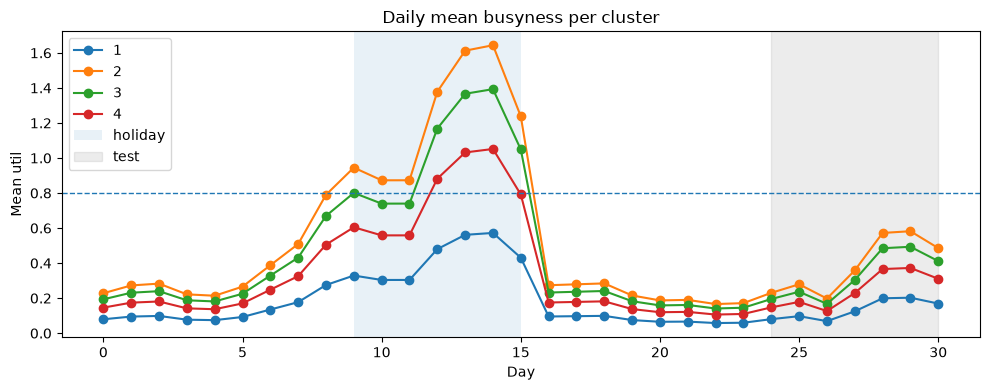

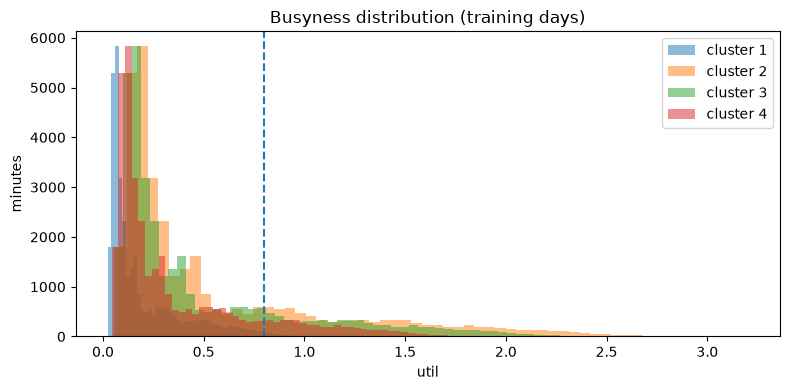

In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. load the table and the rate ----
df = pd.read_parquet(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.parquet")
with open(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.json") as f:
    meta = json.load(f)
PER_POD_RATE = meta["assumptions"]["per_pod_rate_ps_estimate"]   # 26.9
print("PER_POD_RATE =", round(PER_POD_RATE, 2))


df["capacity_ps"] = df["servers"] * PER_POD_RATE
df["util"] = df["arrivals_ps"] / df["capacity_ps"].replace(0, np.nan)   # avoid dividing by 0

# ---- 3. the key numbers, training days only ----
train = df[df["split"] == "train"]
print("\nBusyness on training days, per cluster:")
summary = train.groupby("cluster")["util"].describe(percentiles=[0.5, 0.9, 0.99])
print(summary[["50%", "90%", "99%", "max"]].round(2))

share_busy = (train["util"] >= 0.8).mean()
print(f"\nShare of training rows with util >= 0.8: {share_busy:.1%}")
print("Rows with util >= 1.0 (overloaded):", int((train["util"] >= 1.0).sum()))

# ---- 4. chart A: daily average busyness per cluster ----
daily = df.groupby(["day", "cluster"])["util"].mean().unstack()
ax = daily.plot(marker="o", figsize=(10, 4))
ax.axvspan(9, 15, alpha=0.1, label="holiday")
ax.axvspan(24, 30, alpha=0.15, color="grey", label="test")
ax.axhline(0.8, linestyle="--", linewidth=1)          # "busy" line
ax.set_xlabel("Day"); ax.set_ylabel("Mean util"); ax.set_title("Daily mean busyness per cluster")
ax.legend(); plt.tight_layout(); plt.show()

# ---- 5. chart B: how busyness is spread out ----
plt.figure(figsize=(8, 4))
for c, part in train.groupby("cluster"):
    plt.hist(part["util"].dropna(), bins=60, alpha=0.5, label=f"cluster {c}")
plt.axvline(0.8, linestyle="--")
plt.xlabel("util"); plt.ylabel("minutes"); plt.title("Busyness distribution (training days)")
plt.legend(); plt.tight_layout(); plt.show()

In [33]:
# region-wide numbers per minute (all clusters together), training days only
region = train.groupby("minute").agg(arrivals=("arrivals_ps", "sum"),
                                     servers=("servers", "sum"))
region["per_pod"] = region["arrivals"] / region["servers"]

print(region["per_pod"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

# how often is the WHOLE region over capacity with the current rate?
region["L"] = region["per_pod"] / PER_POD_RATE
print("minutes with region util >= 1:", int((region["L"] >= 1).sum()), "of", len(region))

# the proposed rate: the busiest per-pod rate actually achieved
NEW_RATE = region["per_pod"].quantile(0.99)
print("NEW_RATE (p99) =", round(NEW_RATE, 2))

# busyness per cluster with the new rate
df["util_new"] = df["arrivals_ps"] / (df["servers"] * NEW_RATE)
t = df[df["split"] == "train"]
print(t.groupby("cluster")["util_new"].quantile([0.5, 0.9, 0.99]).unstack().round(2))
print("rows with util_new >= 1:", int((t["util_new"] >= 1).sum()))

count    34560.00
mean        10.19
std         10.04
min          1.20
50%          5.53
90%         26.38
99%         42.26
max         57.99
Name: per_pod, dtype: float64
minutes with region util >= 1: 3264 of 34560
NEW_RATE (p99) = 42.26
         0.50  0.90  0.99
cluster                  
1        0.07  0.32  0.52
2        0.19  0.93  1.49
3        0.16  0.79  1.26
4        0.12  0.59  0.95
rows with util_new >= 1: 4613


In [34]:
SLO_MS = train["svc_p99_ms"].quantile(0.90)
print("SLO_MS =", round(SLO_MS, 1))

SLO_MS = 678.7


In [36]:
import pandas as pd, numpy as np

df = pd.read_parquet(r"C:\Users\Aarya-2\Documents\ADOG\MARLOW AI\CPHarn\Z-heal\data\processed\huawei_region2.parquet")

RATE = 42.26
df["capacity_ps"] = df["servers"] * RATE
df["util"] = df["arrivals_ps"] / df["capacity_ps"].replace(0, np.nan)

# spare room: free capacity in the OTHER zones, per minute per zone
cap  = df.pivot(index="minute", columns="cluster", values="capacity_ps")
arr  = df.pivot(index="minute", columns="cluster", values="arrivals_ps")
free = (cap - arr).clip(lower=0)

spare = {}
for z in cap.columns:
    others = [k for k in cap.columns if k != z]
    spare[z] = free[others].sum(axis=1) / cap[others].sum(axis=1)
spare = pd.DataFrame(spare).stack().rename("spare").reset_index()
spare.columns = ["minute", "cluster", "spare"]
df = df.merge(spare, on=["minute", "cluster"], how="left")

train = df[df["split"] == "train"]
u = train["util"].quantile([0.25, 0.50, 0.75]).round(3).tolist()
s = train["spare"].quantile([0.33, 0.67]).round(3).tolist()

print("UTIL_EDGES  =", sorted(set(u + [0.9])))
print("SPARE_EDGES =", s)

UTIL_EDGES  = [0.078, 0.135, 0.317, 0.9]
SPARE_EDGES = [0.771, 0.91]
